<a href="https://colab.research.google.com/github/Linn-ds/DataScienceJourney/blob/main/ThailandInflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Thailand Inflation Analysis

This notebook performs an exploratory data analysis of various inflation categories in Thailand from 1970 to 2022. The analysis includes data loading, cleaning, transformation, time series visualization, identification of peak inflation years, and correlation analysis.

In [422]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

### Initial Setup and Library Imports

This section imports all necessary libraries for data manipulation, visualization, and warning management.

In [423]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/GlobalInflation/Global Dataset of Inflation.csv', encoding='latin1')

dataset.head()

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,1970,1971,1972,1973,1974,...,2019,2020,2021,2022,Note,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63
0,ABW,314.0,Aruba,Inflation,Headline Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,4.26,1.22,0.74,6.04,Annual average inflation,NaN,NaN,NaN,NaN,NaN
1,AFG,512.0,Afghanistan,Inflation,Headline Consumer Price Inflation,25.51,25.51,-12.52,-10.68,10.23,...,2.30,5.44,5.06,NaN,Annual average inflation,NaN,NaN,NaN,NaN,NaN
2,AGO,614.0,Angola,Inflation,Headline Consumer Price Inflation,7.97,5.78,15.80,15.67,27.42,...,17.08,21.02,23.85,21.35,Annual average inflation,NaN,NaN,NaN,NaN,NaN
3,ALB,914.0,Albania,Inflation,Headline Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,1.41,1.62,2.04,6.73,Annual average inflation,NaN,NaN,NaN,NaN,NaN
4,ARE,466.0,United Arab Emirates,Inflation,Headline Consumer Price Inflation,21.98,21.98,21.98,21.98,21.98,...,-1.93,-2.08,0.18,5.22,Annual average inflation,NaN,NaN,NaN,NaN,NaN


### Data Loading

Here, the global inflation dataset is loaded from a CSV file into a pandas DataFrame. The `head()` method is used to display the first few rows, providing a quick glance at the data structure and content.

In [424]:
print(dataset.shape)

(783, 64)


In [425]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 64 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country Code      783 non-null    object 
 1   IMF Country Code  781 non-null    float64
 2   Country           783 non-null    object 
 3   Indicator Type    783 non-null    object 
 4   Series Name       783 non-null    object 
 5   1970              422 non-null    float64
 6   1971              428 non-null    float64
 7   1972              430 non-null    float64
 8   1973              430 non-null    float64
 9   1974              434 non-null    float64
 10  1975              434 non-null    float64
 11  1976              430 non-null    float64
 12  1977              427 non-null    float64
 13  1978              428 non-null    float64
 14  1979              428 non-null    float64
 15  1980              433 non-null    float64
 16  1981              451 non-null    float64
 1

### Initial Data Overview and Inspection

This step involves checking the shape (number of rows and columns) and general information (`info()`) of the loaded dataset. This helps in understanding the data types, non-null counts, and memory usage, which are crucial for subsequent cleaning and analysis steps.

In [426]:
dataset.drop(columns=dataset.columns[-5:], inplace=True)

dataset.columns

Index(['Country Code', 'IMF Country Code', 'Country', 'Indicator Type',
       'Series Name', '1970', '1971', '1972', '1973', '1974', '1975', '1976',
       '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985',
       '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', 'Note'],
      dtype='object')

In [427]:
dataset.head()

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,1970,1971,1972,1973,1974,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Note
0,ABW,314.0,Aruba,Inflation,Headline Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,0.42,0.48,-0.89,-0.47,3.58,4.26,1.22,0.74,6.04,Annual average inflation
1,AFG,512.0,Afghanistan,Inflation,Headline Consumer Price Inflation,25.51,25.51,-12.52,-10.68,10.23,...,4.67,-0.66,4.38,4.98,0.63,2.30,5.44,5.06,NaN,Annual average inflation
2,AGO,614.0,Angola,Inflation,Headline Consumer Price Inflation,7.97,5.78,15.80,15.67,27.42,...,7.30,9.16,32.38,29.84,19.63,17.08,21.02,23.85,21.35,Annual average inflation
3,ALB,914.0,Albania,Inflation,Headline Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,1.62,1.91,1.29,1.99,2.03,1.41,1.62,2.04,6.73,Annual average inflation
4,ARE,466.0,United Arab Emirates,Inflation,Headline Consumer Price Inflation,21.98,21.98,21.98,21.98,21.98,...,2.34,4.07,1.62,1.97,3.06,-1.93,-2.08,0.18,5.22,Annual average inflation


In [428]:
dataset.isnull().sum() , dataset.shape

(Country Code          0
 IMF Country Code      2
 Country               0
 Indicator Type        0
 Series Name           0
 1970                361
 1971                355
 1972                353
 1973                353
 1974                349
 1975                349
 1976                353
 1977                356
 1978                355
 1979                355
 1980                350
 1981                332
 1982                325
 1983                319
 1984                313
 1985                317
 1986                308
 1987                301
 1988                298
 1989                300
 1990                294
 1991                276
 1992                264
 1993                247
 1994                231
 1995                224
 1996                213
 1997                208
 1998                199
 1999                192
 2000                187
 2001                173
 2002                158
 2003                154
 2004                149


### Data Filtering and Preprocessing for Thailand

In this crucial phase, the dataset is filtered to isolate inflation data specifically for 'Thailand'. Following this, several preprocessing steps are applied:

*   **Column Dropping**: Irrelevant columns are removed.
*   **Transposing**: The DataFrame is transposed to convert years into rows, making it suitable for time series analysis.
*   **Header Correction**: The first row, which now contains `Series Name` values, is promoted to become the column headers, and the original index column is renamed to 'Year'.
*   **Note Extraction**: The last row, which contains notes about the inflation series, is extracted and then dropped from the main DataFrame to ensure only numerical data remains.
*   **Data Type Conversion**: Columns representing inflation rates (which were originally loaded as objects) are converted to numeric types (float), and the 'Year' column is converted to integer type. Missing values are filled with 0 to ensure numerical operations can be performed without errors.

In [429]:
inf_thai = dataset[dataset['Country'] == 'Thailand']

inf_thai

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,1970,1971,1972,1973,1974,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Note
170,THA,578.0,Thailand,Inflation,Headline Consumer Price Inflation,0.80,0.29,5.01,15.63,24.32,...,1.89,-0.90,0.19,0.67,1.07,0.71,-0.85,1.23,6.08,Annual average inflation
353,THA,578.0,Thailand,Inflation,Energy Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,1.41,0.59,-1.00,0.17,1.03,0.42,-1.02,-1.72,5.06,"Housing, Water, Electricity, Gas & Other Fuel"
533,THA,578.0,Thailand,Inflation,Food Consumer Price Inflation,0.20,0.60,6.40,14.40,28.50,...,3.94,1.13,1.61,0.00,0.41,2.31,1.23,-0.13,6.49,Food and non-acoholic beverage
655,THA,578.0,Thailand,Inflation,Official Core Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,0.64,0.89,0.69,0.33,0.53,0.36,0.07,0.00,0.54,All Items Excluding Food and Energy
766,THA,578.0,Thailand,Inflation,Producer Price Inflation,-0.46,0.25,7.84,22.92,28.86,...,0.14,-4.11,-1.18,0.70,0.38,-0.96,-1.60,4.72,10.90,"Producer Price Index, All Commodities"


In [430]:
inf_thai['Series Name'].unique()

array(['Headline Consumer Price Inflation',
       'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
       'Official Core Consumer Price Inflation',
       'Producer Price Inflation'], dtype=object)

In [431]:
inf_thai.drop(columns= inf_thai.columns[:4], inplace=True)

inf_thai

,Series Name,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Note
170,Headline Consumer Price Inflation,0.80,0.29,5.01,15.63,24.32,5.10,4.24,7.62,7.99,...,1.89,-0.90,0.19,0.67,1.07,0.71,-0.85,1.23,6.08,Annual average inflation
353,Energy Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.41,0.59,-1.00,0.17,1.03,0.42,-1.02,-1.72,5.06,"Housing, Water, Electricity, Gas & Other Fuel"
533,Food Consumer Price Inflation,0.20,0.60,6.40,14.40,28.50,4.00,5.50,9.38,8.68,...,3.94,1.13,1.61,0.00,0.41,2.31,1.23,-0.13,6.49,Food and non-acoholic beverage
655,Official Core Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.64,0.89,0.69,0.33,0.53,0.36,0.07,0.00,0.54,All Items Excluding Food and Energy
766,Producer Price Inflation,-0.46,0.25,7.84,22.92,28.86,3.71,3.94,7.80,7.46,...,0.14,-4.11,-1.18,0.70,0.38,-0.96,-1.60,4.72,10.90,"Producer Price Index, All Commodities"


In [432]:
inf_thai = inf_thai.transpose()

inf_thai.head()

,170,353,533,655,766
Series Name,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1970,0.8,NaN,0.2,NaN,-0.46
1971,0.29,NaN,0.6,NaN,0.25
1972,5.01,NaN,6.4,NaN,7.84
1973,15.63,NaN,14.4,NaN,22.92


In [433]:
inf_thai = inf_thai.reset_index()

inf_thai.head()

,index,170,353,533,655,766
0,Series Name,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.8,NaN,0.2,NaN,-0.46
2,1971,0.29,NaN,0.6,NaN,0.25
3,1972,5.01,NaN,6.4,NaN,7.84
4,1973,15.63,NaN,14.4,NaN,22.92


In [434]:
inf_thai.columns = inf_thai.iloc[0]

inf_thai.drop(inf_thai.index[0], inplace=True)

inf_thai

,Series Name,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.8,NaN,0.2,NaN,-0.46
2,1971,0.29,NaN,0.6,NaN,0.25
3,1972,5.01,NaN,6.4,NaN,7.84
4,1973,15.63,NaN,14.4,NaN,22.92
5,1974,24.32,NaN,28.5,NaN,28.86
6,1975,5.1,NaN,4.0,NaN,3.71
7,1976,4.24,NaN,5.5,NaN,3.94
8,1977,7.62,NaN,9.38,NaN,7.8
9,1978,7.99,NaN,8.68,NaN,7.46
10,1979,9.81,NaN,9.17,NaN,11.21


In [435]:
inf_thai = inf_thai.rename(columns={'Series Name': 'Year'})

In [436]:
inf_thai

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.8,NaN,0.2,NaN,-0.46
2,1971,0.29,NaN,0.6,NaN,0.25
3,1972,5.01,NaN,6.4,NaN,7.84
4,1973,15.63,NaN,14.4,NaN,22.92
5,1974,24.32,NaN,28.5,NaN,28.86
6,1975,5.1,NaN,4.0,NaN,3.71
7,1976,4.24,NaN,5.5,NaN,3.94
8,1977,7.62,NaN,9.38,NaN,7.8
9,1978,7.99,NaN,8.68,NaN,7.46
10,1979,9.81,NaN,9.17,NaN,11.21


In [437]:
inf_thai.info(),
inf_thai.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 1 to 54
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Year                                    54 non-null     object
 1   Headline Consumer Price Inflation       54 non-null     object
 2   Energy Consumer Price Inflation         17 non-null     object
 3   Food Consumer Price Inflation           54 non-null     object
 4   Official Core Consumer Price Inflation  38 non-null     object
 5   Producer Price Inflation                54 non-null     object
dtypes: object(6)
memory usage: 2.7+ KB


,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
count,54,54.0,17.0,54.00,38.00,54.00
unique,54,53.0,17.0,53.00,37.00,53.00
top,1970,0.8,63.0,4.95,0.82,-0.42
freq,1,2.0,1.0,2.00,2.00,2.00


In [438]:
note = inf_thai.iloc[-1:]
note = note.reset_index()
note.drop(columns=['index','Year'], inplace=True)

note

,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
0,Annual average inflation,"Housing, Water, Electricity, Gas & Other Fuel",Food and non-acoholic beverage,All Items Excluding Food and Energy,"Producer Price Index, All Commodities"


In [439]:
inf_thai.drop(inf_thai.index[-1], inplace=True)

inf_thai

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.8,NaN,0.2,NaN,-0.46
2,1971,0.29,NaN,0.6,NaN,0.25
3,1972,5.01,NaN,6.4,NaN,7.84
4,1973,15.63,NaN,14.4,NaN,22.92
5,1974,24.32,NaN,28.5,NaN,28.86
6,1975,5.1,NaN,4.0,NaN,3.71
7,1976,4.24,NaN,5.5,NaN,3.94
8,1977,7.62,NaN,9.38,NaN,7.8
9,1978,7.99,NaN,8.68,NaN,7.46
10,1979,9.81,NaN,9.17,NaN,11.21


In [440]:
inf_thai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 1 to 53
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Year                                    53 non-null     object
 1   Headline Consumer Price Inflation       53 non-null     object
 2   Energy Consumer Price Inflation         16 non-null     object
 3   Food Consumer Price Inflation           53 non-null     object
 4   Official Core Consumer Price Inflation  37 non-null     object
 5   Producer Price Inflation                53 non-null     object
dtypes: object(6)
memory usage: 2.6+ KB


In [441]:
inf_thai = inf_thai.astype(float)
inf_thai['Year']=inf_thai['Year'].astype(int)

inf_thai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 1 to 53
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Year                                    53 non-null     int64  
 1   Headline Consumer Price Inflation       53 non-null     float64
 2   Energy Consumer Price Inflation         16 non-null     float64
 3   Food Consumer Price Inflation           53 non-null     float64
 4   Official Core Consumer Price Inflation  37 non-null     float64
 5   Producer Price Inflation                53 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.6 KB


In [442]:
inf_thai.head()

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.80,NaN,0.2,NaN,-0.46
2,1971,0.29,NaN,0.6,NaN,0.25
3,1972,5.01,NaN,6.4,NaN,7.84
4,1973,15.63,NaN,14.4,NaN,22.92
5,1974,24.32,NaN,28.5,NaN,28.86


In [443]:
inf_thai.fillna(0, inplace=True)

inf_thai.head()

,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation
1,1970,0.80,0.0,0.2,0.0,-0.46
2,1971,0.29,0.0,0.6,0.0,0.25
3,1972,5.01,0.0,6.4,0.0,7.84
4,1973,15.63,0.0,14.4,0.0,22.92
5,1974,24.32,0.0,28.5,0.0,28.86


### Time Series Analysis and Visualization

This section focuses on visualizing the trends of different inflation categories over time for Thailand. Line plots are generated for each inflation type, allowing for an easy comparison of their historical behavior and identification of periods of high or low inflation.

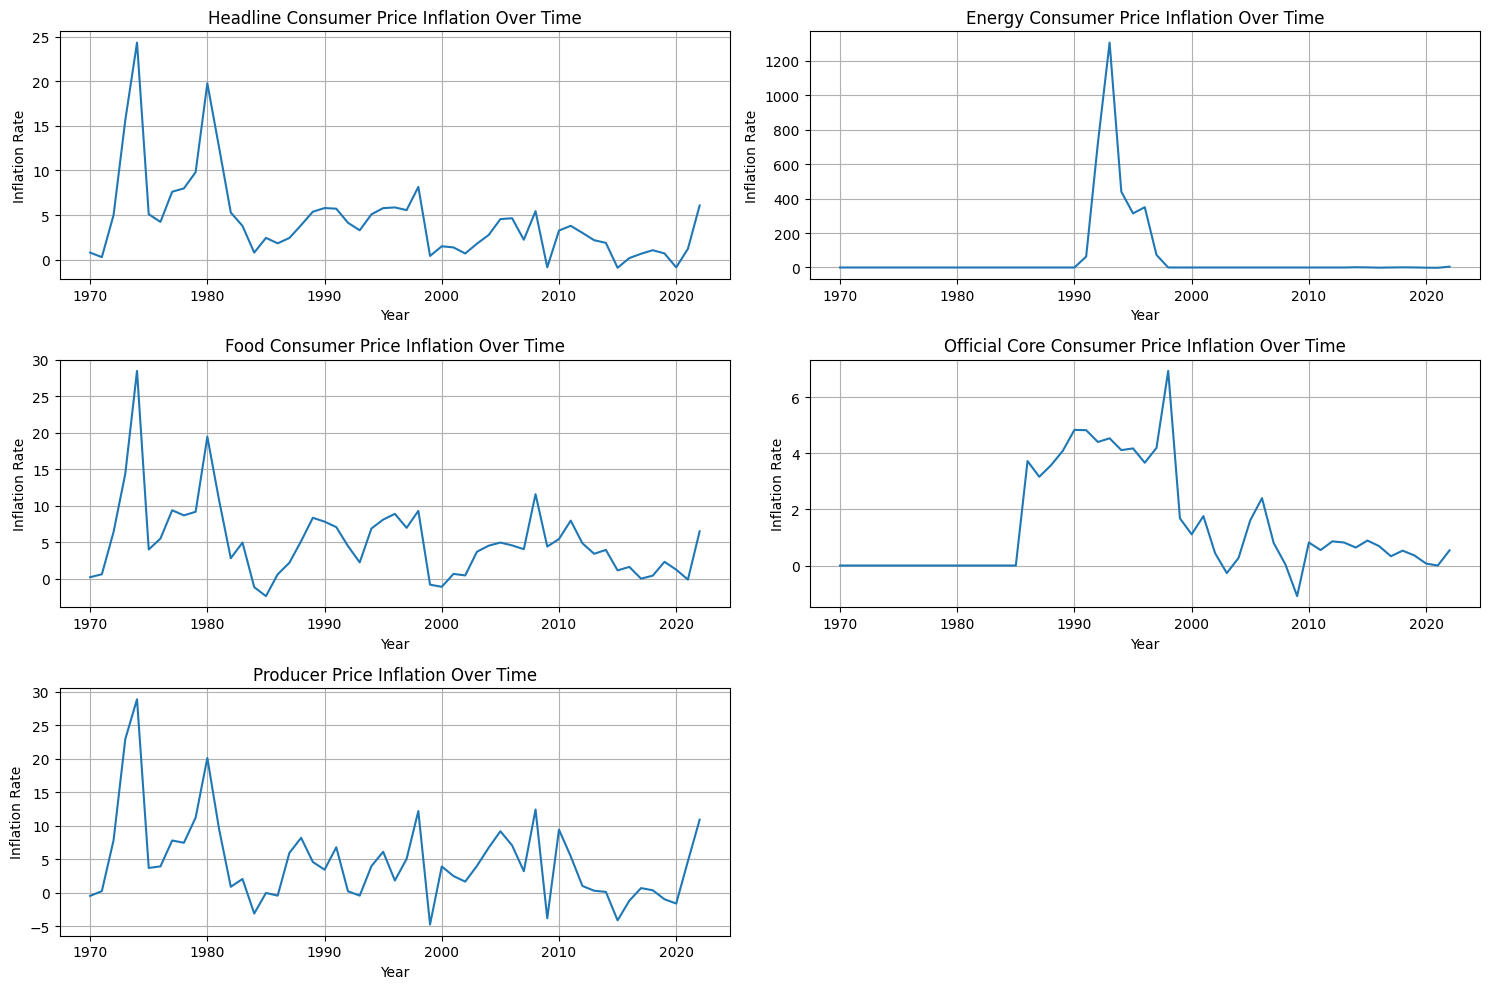

In [444]:
inflation_types = inf_thai.columns.drop('Year')

plt.figure(figsize=(15, 10))
for i, col in enumerate(inflation_types):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    plt.plot(inf_thai['Year'], inf_thai[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel('Inflation Rate')
    plt.grid(True)

plt.tight_layout()
plt.show()

Correlation Matrix of Inflation Categories:
0                                       Headline Consumer Price Inflation  \
0                                                                           
Headline Consumer Price Inflation                                1.000000   
Energy Consumer Price Inflation                                 -0.006172   
Food Consumer Price Inflation                                    0.927038   
Official Core Consumer Price Inflation                           0.013557   
Producer Price Inflation                                         0.892396   

0                                       Energy Consumer Price Inflation  \
0                                                                         
Headline Consumer Price Inflation                             -0.006172   
Energy Consumer Price Inflation                                1.000000   
Food Consumer Price Inflation                                 -0.019287   
Official Core Consumer Price Inflation   

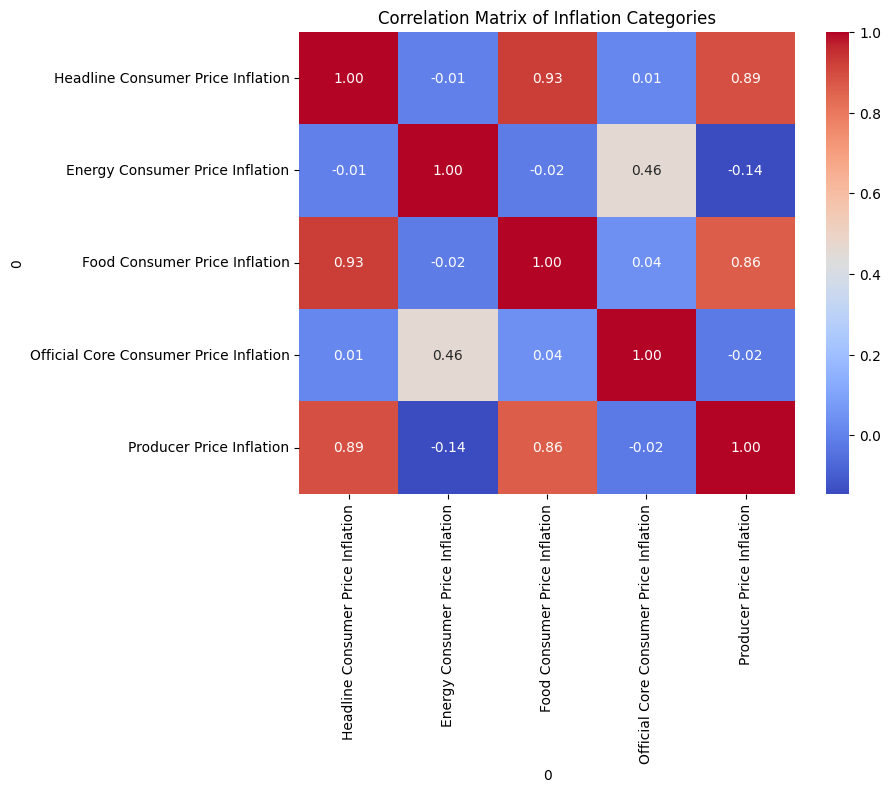

In [445]:
correlation_matrix = inf_thai.drop(columns=['Year']).corr()
print("Correlation Matrix of Inflation Categories:")
print(correlation_matrix)

# Optional: Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Inflation Categories')
plt.show()

#### Interpretation of the Correlation Matrix and Heatmap

The correlation matrix and its visual representation as a heatmap provide insights into how different inflation categories in Thailand move in relation to each other.

*   **Strong Positive Correlations**:
    *   `Headline Consumer Price Inflation` shows a very strong positive correlation with `Food Consumer Price Inflation` (0.93) and `Producer Price Inflation` (0.89). This suggests that changes in food prices and producer prices are major drivers of overall headline inflation.
    *   `Food Consumer Price Inflation` and `Producer Price Inflation` also have a strong positive correlation (0.86), indicating they often rise and fall together.

*   **Moderate Positive Correlation**:
    *   `Energy Consumer Price Inflation` has a moderate positive correlation with `Official Core Consumer Price Inflation` (0.46). This implies that energy prices can influence core inflation, though other factors also play a significant role in core inflation.

*   **Weak or Negative Correlations**:
    *   `Energy Consumer Price Inflation` shows very weak or slightly negative correlations with `Headline`, `Food`, and `Producer Price Inflation`. This indicates that energy price movements often behave somewhat independently of the broader inflation categories, or even in an inverse direction, suggesting unique drivers for energy inflation.
    *   `Official Core Consumer Price Inflation` has weak correlations with `Headline`, `Food`, and `Producer Price Inflation`, suggesting that policies and factors influencing core inflation might be distinct from those affecting these other categories.

### Correlation Analysis of Inflation Categories

Here, a correlation matrix is computed to quantify the relationships between different inflation types. A heatmap visualization provides a clear and intuitive representation of these correlations, indicating which inflation categories tend to move together (positive correlation) or in opposite directions (negative correlation).

In [446]:
print("Years with highest inflation for each category:")
for col in inflation_types:
    max_inflation_value = inf_thai[col].max()
    # Handle cases where multiple years have the same maximum inflation
    years_with_max = inf_thai[inf_thai[col] == max_inflation_value]['Year'].tolist()
    print(f"  {col}: {max_inflation_value:.2f}% in {years_with_max}")

Years with highest inflation for each category:
  Headline Consumer Price Inflation: 24.32% in [1974]
  Energy Consumer Price Inflation: 1304.20% in [1993]
  Food Consumer Price Inflation: 28.50% in [1974]
  Official Core Consumer Price Inflation: 6.93% in [1998]
  Producer Price Inflation: 28.86% in [1974]


### Identifying Peak Inflation Years

This analysis pinpoints the specific years when each inflation category experienced its highest rate. This helps in understanding historical economic events that might have led to these peaks.

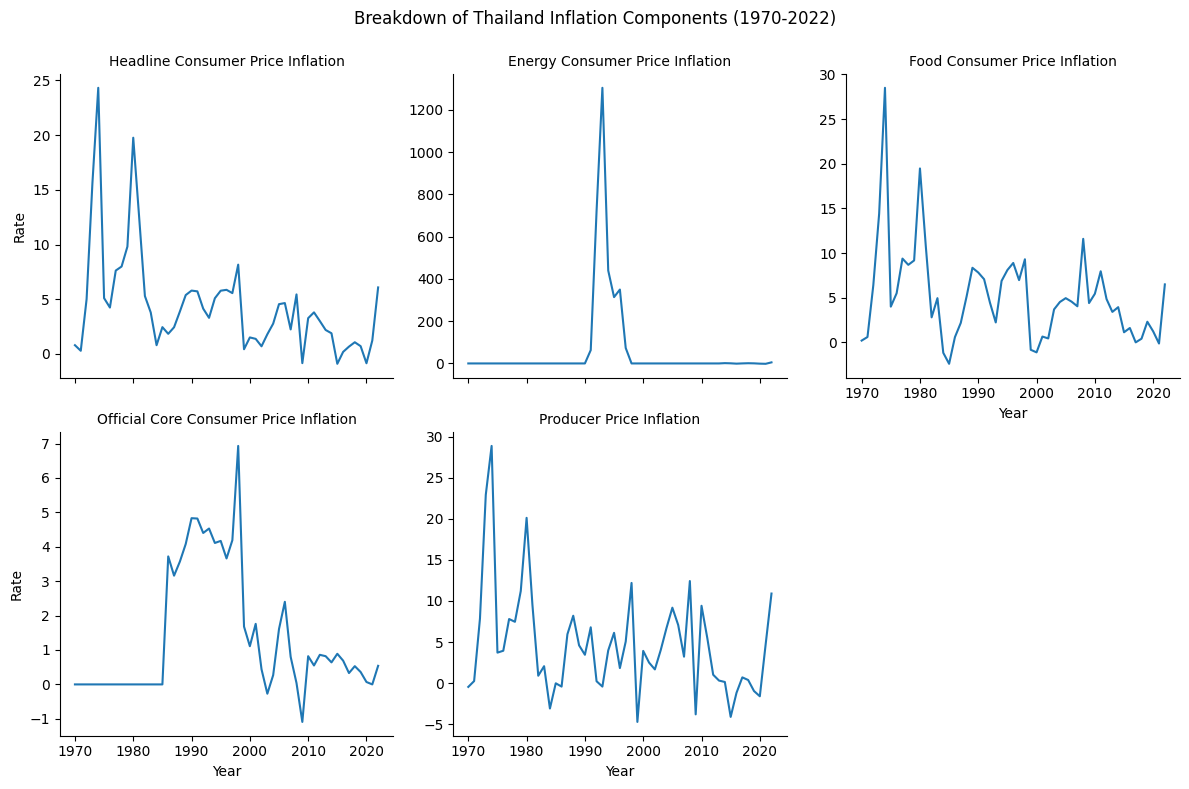

In [447]:
# Melt the data into 'Long Format' for Seaborn
inf_thai_long = inf_thai.melt(id_vars='Year', var_name='Inflation_Type', value_name='Rate')

# Create a FacetGrid to see each inflation type clearly
g = sns.FacetGrid(inf_thai_long, col="Inflation_Type", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "Year", "Rate")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Breakdown of Thailand Inflation Components (1970-2022)')
plt.show()

### Alternative Time Series Visualization with FacetGrid

This section uses Seaborn's FacetGrid to provide an alternative visualization of the time series data. By melting the DataFrame into a 'long' format, it allows for individual plots of each inflation type within a grid, offering a more detailed view for each category.

## Key Economic Insights from Thailand Inflation Analysis (1970-2022)

This exploratory data analysis of Thailand's inflation landscape between 1970 and 2022 has revealed several important economic insights:

1.  **Dominance of Headline, Food, and Producer Price Inflation**: The time series plots clearly show that 'Headline Consumer Price Inflation', 'Food Consumer Price Inflation', and 'Producer Price Inflation' exhibit similar cyclical patterns and significant magnitudes. This is further reinforced by their strong positive correlations (e.g., Headline with Food: 0.93, Headline with Producer Price: 0.89), suggesting that food prices and production costs are primary drivers of overall inflation in Thailand.

2.  **Historical Peaks in Inflation**: The analysis identified specific years with the highest inflation rates for each category:
    *   **1974** stands out for **Headline Consumer Price Inflation (24.32%)**, **Food Consumer Price Inflation (28.50%)**, and **Producer Price Inflation (28.86%)**. This indicates a period of broad inflationary pressure, likely driven by global and domestic economic factors of that era.
    *   **1993** saw an extraordinary peak in **Energy Consumer Price Inflation (1304.20%)**. This anomaly points to a specific event or policy change impacting energy costs disproportionately during that year.
    *   **1998** registered the highest **Official Core Consumer Price Inflation (6.93%)**. This period coincides with the Asian Financial Crisis, suggesting that even core inflation, which typically excludes volatile items, was significantly impacted.

3.  **Distinct Behavior of Energy and Core Inflation**: While there's a moderate positive correlation between Energy and Official Core Consumer Price Inflation (0.46), Energy inflation generally shows weak or even slightly negative correlations with the broader inflation categories (Headline, Food, Producer Price). This implies that energy price dynamics are often influenced by different factors (e.g., global oil prices, energy subsidies) than those driving general consumption and production costs. Similarly, Official Core inflation tends to follow a different trajectory than food and producer prices, reflecting the underlying, less volatile price pressures in the economy.

In conclusion, understanding these distinct and correlated behaviors among different inflation components is crucial for policymakers in Thailand to formulate targeted monetary and fiscal policies to maintain price stability and foster economic growth.